<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/FluidMechanics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Fluid mechanics with NeqSim: single-phase gas pipeline hydraulics

**Audience.** Process, pipeline, and flow-assurance engineers who want a transparent introduction to
steady pipeline hydraulics coupled to a real-fluid equation of state.

**Prerequisites.** Basic Python, conservation equations, and SI units. The deterministic synthetic
gas contains no proprietary data. All pressures are absolute unless explicitly noted.


In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )


## Learning objectives

After completing the notebook you can:

1. construct a gas fluid, stream, and `PipeBeggsAndBrills` pipeline with current NeqSim APIs;
2. connect continuity, Reynolds number, friction factor, and pressure loss to model results;
3. inspect pressure, density, velocity, and Reynolds-number profiles;
4. quantify length, diameter, roughness, flow-rate, and elevation sensitivities;
5. verify phase stability, mass closure, finite outputs, and expected engineering trends; and
6. state where a steady correlation is appropriate and where higher-fidelity modelling is required.


In [2]:
import importlib.metadata
import math
import platform

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim


Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = (
    jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
)

neqsim_version = importlib.metadata.version("neqsim")
python_version = platform.python_version()
java_version = jpype.JClass("java.lang.System").getProperty("java.version")

plt.style.use("seaborn-v0_8-whitegrid")
print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {python_version}")
print(f"Java version: {java_version}")


NeqSim version: 3.16.0
Python version: 3.12.13
Java version: 17.0.19


## Governing equations and scope

For steady one-dimensional flow, mass conservation is

$$
\dot m = \rho u A
$$

where $\dot m$ is mass flow in kg/s, $\rho$ is density in kg/m$^3$, $u$ is mean velocity in m/s,
and $A$ is internal area in m$^2$. Reynolds number compares inertial and viscous forces:

$$
\mathrm{Re} = \frac{\rho u D}{\mu}
$$

Here $D$ is internal diameter in m and $\mu$ is dynamic viscosity in Pa s. The model is steady,
one-dimensional, and equilibrium based. It does not resolve fittings, acoustic transients, detailed
turbulence, local geometry, terrain-induced slugging, erosion, or wall heat transfer unless these are
explicitly represented.


In [3]:
inlet_temperature_k = 298.15
inlet_pressure_bara = 80.0
mass_flow_kg_s = 100000.0 / 3600.0
pipe_length_m = 10000.0
pipe_diameter_m = 0.50
pipe_roughness_m = 4.5e-5
pipe_elevation_m = 0.0
number_of_increments = 20

composition = {
    "methane": 0.90,
    "ethane": 0.06,
    "propane": 0.03,
    "nitrogen": 0.01,
}


def create_gas():
    fluid = jneqsim.thermo.system.SystemSrkEos(
        inlet_temperature_k,
        inlet_pressure_bara,
    )
    for component, fraction in composition.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)
    return fluid


## Fluid and model choices

The Soave–Redlich–Kwong equation of state is a practical cubic model for hydrocarbon-gas phase
equilibrium and density. The classic mixing rule is explicit. `Stream` supplies a mass-flow basis, and
`PipeBeggsAndBrills` performs segmented pressure-drop calculations while updating thermodynamic and
transport properties. Although Beggs–Brill is best known for multiphase flow, NeqSim also reports a
single-phase regime for this dry-gas case.

This synthetic composition is suitable for teaching, not custody transfer or project design. A real
case needs representative composition, internal diameter, roughness, route elevations, heat transfer,
fittings, and operating uncertainty.


In [4]:
gas_fluid = create_gas()
feed = Stream("Dry gas feed", gas_fluid)
feed.setFlowRate(mass_flow_kg_s, "kg/sec")
feed.setTemperature(inlet_temperature_k, "K")
feed.setPressure(inlet_pressure_bara, "bara")
feed.run()

feed_fluid = feed.getFluid()
feed_fluid.initProperties()
feed_fluid.initPhysicalProperties()
gas_phase = feed_fluid.getPhase("gas")

composition_table = pd.DataFrame(
    {
        "Component": list(composition),
        "Mole fraction [mol/mol]": list(composition.values()),
    }
)
print(composition_table.to_string(index=False))


Component  Mole fraction [mol/mol]
  methane                     0.90
   ethane                     0.06
  propane                     0.03
 nitrogen                     0.01


## Inlet diagnostics

Before solving hydraulics, verify the phase, flow basis, and transport properties. The cross-sectional
area is $A=\pi D^2/4$. Continuity then provides an independent velocity. A phase error or a flow-unit
mistake can dominate every downstream result, so these checks are not optional.


In [5]:
pipe_area_m2 = math.pi * pipe_diameter_m**2 / 4.0
inlet_density_kg_m3 = gas_phase.getDensity("kg/m3")
inlet_viscosity_pa_s = gas_phase.getViscosity("kg/msec")
continuity_velocity_m_s = mass_flow_kg_s / (
    inlet_density_kg_m3 * pipe_area_m2
)
reynolds_number = (
    inlet_density_kg_m3
    * continuity_velocity_m_s
    * pipe_diameter_m
    / inlet_viscosity_pa_s
)

inlet_table = pd.Series(
    {
        "Temperature [K]": feed.getTemperature("K"),
        "Pressure [bara]": feed.getPressure("bara"),
        "Mass flow [kg/s]": feed.getFlowRate("kg/sec"),
        "Density [kg/m3]": inlet_density_kg_m3,
        "Viscosity [Pa s]": inlet_viscosity_pa_s,
        "Compressibility factor [-]": feed_fluid.getZ(),
        "Sound speed [m/s]": gas_phase.getSoundSpeed(),
        "Continuity velocity [m/s]": continuity_velocity_m_s,
        "Reynolds number [-]": reynolds_number,
    }
)
print(inlet_table.to_string())


Temperature [K]               2.981500e+02
Pressure [bara]               8.000000e+01
Mass flow [kg/s]              2.777778e+01
Density [kg/m3]               6.815275e+01
Viscosity [Pa s]              1.341886e-05
Compressibility factor [-]    8.480613e-01
Sound speed [m/s]             4.127093e+02
Continuity velocity [m/s]     2.075794e+00
Reynolds number [-]           5.271353e+06


## Friction reference calculation

For turbulent flow, the Swamee–Jain approximation to the Darcy friction factor is

$$
f_D = \frac{0.25}{\left[\log_{10}\left(\frac{\varepsilon}{3.7D}
+ \frac{5.74}{\mathrm{Re}^{0.9}}\right)\right]^2}
$$

The incompressible Darcy–Weisbach reference is

$$
\Delta p = f_D \frac{L}{D}\frac{\rho u^2}{2}
$$

It freezes density and velocity at the inlet, so it is only an order-of-magnitude check for real gas.
The segmented NeqSim model updates properties as pressure changes.


In [6]:
relative_roughness = pipe_roughness_m / pipe_diameter_m
darcy_friction_factor = 0.25 / (
    math.log10(
        relative_roughness / 3.7
        + 5.74 / reynolds_number**0.9
    )
    ** 2
)
darcy_pressure_drop_bara = (
    darcy_friction_factor
    * pipe_length_m
    / pipe_diameter_m
    * inlet_density_kg_m3
    * continuity_velocity_m_s**2
    / 2.0
    / 1.0e5
)

print(f"Relative roughness [-]: {relative_roughness:.3e}")
print(f"Darcy friction factor [-]: {darcy_friction_factor:.6f}")
print(f"Frozen-property pressure drop [bar]: {darcy_pressure_drop_bara:.6f}")


Relative roughness [-]: 9.000e-05
Darcy friction factor [-]: 0.012177
Frozen-property pressure drop [bar]: 0.357603


## NeqSim pipeline base case

The pipeline is horizontal, adiabatic, and divided into 20 increments. Length, diameter, wall
roughness, and elevation are all explicit SI inputs. The model calculates outlet pressure from the
specified inlet state and flow; no outlet-pressure target is imposed.


In [7]:
def run_pipeline(
    mass_flow,
    length=pipe_length_m,
    diameter=pipe_diameter_m,
    roughness=pipe_roughness_m,
    elevation=pipe_elevation_m,
):
    case_fluid = create_gas()
    case_feed = Stream("Case feed", case_fluid)
    case_feed.setFlowRate(float(mass_flow), "kg/sec")
    case_feed.setTemperature(inlet_temperature_k, "K")
    case_feed.setPressure(inlet_pressure_bara, "bara")
    case_feed.run()

    pipeline = PipeBeggsAndBrills("Pipeline case", case_feed)
    pipeline.setLength(float(length))
    pipeline.setDiameter(float(diameter))
    pipeline.setPipeWallRoughness(float(roughness))
    pipeline.setElevation(float(elevation))
    pipeline.setNumberOfIncrements(number_of_increments)
    pipeline.run()
    return case_feed, pipeline, pipeline.getOutletStream()


base_feed, base_pipeline, base_outlet = run_pipeline(mass_flow_kg_s)
base_pressure_drop_bara = (
    base_feed.getPressure("bara") - base_outlet.getPressure("bara")
)
base_mass_residual_kg_s = (
    base_outlet.getFlowRate("kg/sec") - base_feed.getFlowRate("kg/sec")
)

base_results = pd.Series(
    {
        "Outlet pressure [bara]": base_outlet.getPressure("bara"),
        "Pressure drop [bar]": base_pressure_drop_bara,
        "Outlet temperature [K]": base_outlet.getTemperature("K"),
        "Mixture velocity [m/s]": base_pipeline.getMixtureVelocity(),
        "Flow regime": str(base_pipeline.getFlowRegime()),
        "Mass residual [kg/s]": base_mass_residual_kg_s,
    }
)
print(base_results.to_string())


Outlet pressure [bara]       79.644251
Pressure drop [bar]           0.355749
Outlet temperature [K]          298.15
Mixture velocity [m/s]        2.086373
Flow regime               SINGLE_PHASE
Mass residual [kg/s]               0.0


## Reference comparison

The frozen-property Darcy calculation is expected to differ from the segmented correlation because
it omits compressibility and uses a different correlation structure. Agreement in scale is the useful
check. The NeqSim velocity should closely match the inlet continuity value for this small pressure drop.


In [8]:
velocity_residual_m_s = (
    base_pipeline.getMixtureVelocity() - continuity_velocity_m_s
)
pressure_drop_ratio = base_pressure_drop_bara / darcy_pressure_drop_bara

reference_comparison = pd.Series(
    {
        "NeqSim pressure drop [bar]": base_pressure_drop_bara,
        "Frozen-property Darcy drop [bar]": darcy_pressure_drop_bara,
        "Pressure-drop ratio [-]": pressure_drop_ratio,
        "NeqSim velocity [m/s]": base_pipeline.getMixtureVelocity(),
        "Continuity velocity [m/s]": continuity_velocity_m_s,
        "Velocity residual [m/s]": velocity_residual_m_s,
    }
)
print(reference_comparison.to_string())


NeqSim pressure drop [bar]          0.355749
Frozen-property Darcy drop [bar]    0.357603
Pressure-drop ratio [-]             0.994815
NeqSim velocity [m/s]               2.086373
Continuity velocity [m/s]           2.075794
Velocity residual [m/s]             0.010579


## Segmented profiles

Profiles reveal whether the solution is smooth and physically interpretable. The pressure array has
one point per segment boundary. Reynolds number should remain turbulent and change only slightly for
this modest pressure drop. A flat temperature is expected because the pipe is adiabatic in this setup.


In [9]:
pressure_profile_bara = np.array(base_pipeline.getPressureProfile())
reynolds_profile = np.array(base_pipeline.getMixtureReynoldsNumber())
distance_profile_m = np.linspace(
    0.0,
    pipe_length_m,
    pressure_profile_bara.size,
)

profile_table = pd.DataFrame(
    {
        "Distance [m]": distance_profile_m,
        "Pressure [bara]": pressure_profile_bara,
        "Reynolds number [-]": reynolds_profile,
    }
)
print(profile_table.iloc[::5].round(5).to_string(index=False))


 Distance [m]  Pressure [bara]  Reynolds number [-]
          0.0         80.00000         5.267974e+06
       2500.0         79.91123         5.269487e+06
       5000.0         79.82235         5.271003e+06
       7500.0         79.73336         5.272519e+06
      10000.0         79.64425         5.274038e+06


The monotonic pressure profile is a basic numerical-health check. A sudden oscillation or pressure
increase in a horizontal pipe without added work would indicate an input, convergence, or sign problem.


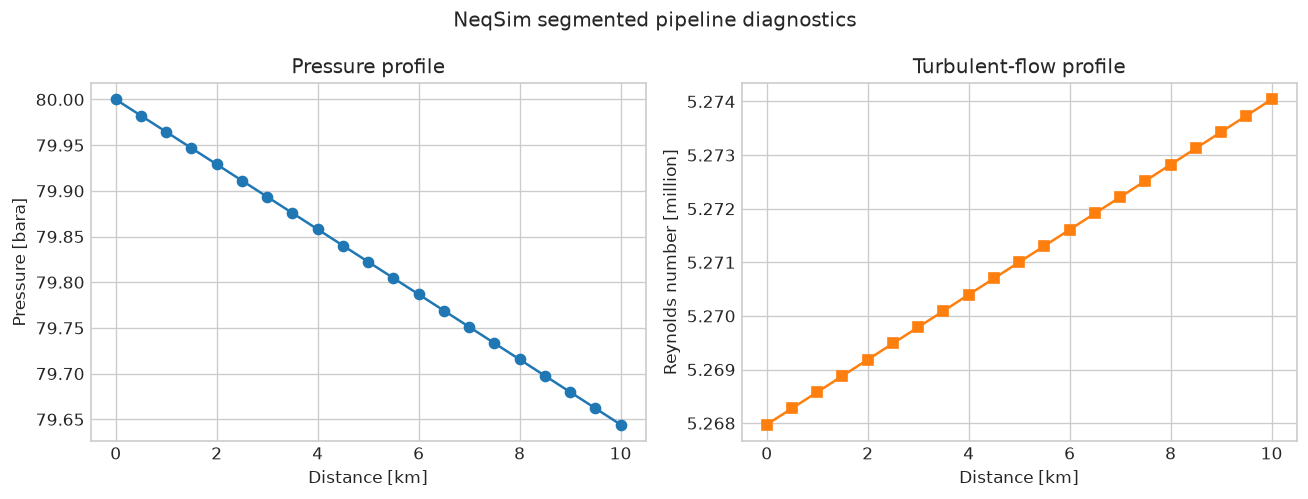

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(
    profile_table["Distance [m]"] / 1000.0,
    profile_table["Pressure [bara]"],
    marker="o",
)
axes[0].set_xlabel("Distance [km]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Pressure profile")

axes[1].plot(
    profile_table["Distance [m]"] / 1000.0,
    profile_table["Reynolds number [-]"] / 1.0e6,
    marker="s",
    color="tab:orange",
)
axes[1].set_xlabel("Distance [km]")
axes[1].set_ylabel("Reynolds number [million]")
axes[1].set_title("Turbulent-flow profile")

fig.suptitle("NeqSim segmented pipeline diagnostics")
fig.tight_layout()
plt.show()


## Length and diameter design study

For fixed flow, frictional loss should increase with length and decrease strongly with diameter.
Diameter changes both area and velocity, so its influence is much stronger than a simple $L/D$ term.
These trends are more reliable than transferring one correlation result outside its calibrated range.


In [11]:
length_grid_m = np.array([2500.0, 5000.0, 7500.0, 10000.0, 12500.0])
length_pressure_drops_bara = []

for length_m in length_grid_m:
    case_feed, _, case_outlet = run_pipeline(
        mass_flow_kg_s,
        length=length_m,
    )
    length_pressure_drops_bara.append(
        case_feed.getPressure("bara") - case_outlet.getPressure("bara")
    )

diameter_grid_m = np.array([0.40, 0.45, 0.50, 0.55, 0.60])
diameter_pressure_drops_bara = []

for diameter_m in diameter_grid_m:
    case_feed, _, case_outlet = run_pipeline(
        mass_flow_kg_s,
        diameter=diameter_m,
    )
    diameter_pressure_drops_bara.append(
        case_feed.getPressure("bara") - case_outlet.getPressure("bara")
    )

design_table = pd.DataFrame(
    {
        "Length [km]": length_grid_m / 1000.0,
        "Length-study drop [bar]": length_pressure_drops_bara,
        "Diameter [m]": diameter_grid_m,
        "Diameter-study drop [bar]": diameter_pressure_drops_bara,
    }
)
print(design_table.round(6).to_string(index=False))


 Length [km]  Length-study drop [bar]  Diameter [m]  Diameter-study drop [bar]
         2.5                 0.088777          0.40                   1.128027
         5.0                 0.177661          0.45                   0.612649
         7.5                 0.266651          0.50                   0.355749
        10.0                 0.355749          0.55                   0.217927
        12.5                 0.444954          0.60                   0.139493


## Roughness and flow-rate sensitivity

Wall roughness represents internal surface condition, not a tuning parameter for missing fittings.
Flow-rate sensitivity is nonlinear because velocity and Reynolds number both change. The study remains
inside a feasible pressure range; a negative outlet pressure would be a deliverability-limit warning,
not a result to clip or ignore.


In [12]:
roughness_grid_m = np.array([1.0e-6, 1.0e-5, 4.5e-5, 1.0e-4, 3.0e-4])
roughness_pressure_drops_bara = []

for roughness_m in roughness_grid_m:
    case_feed, _, case_outlet = run_pipeline(
        mass_flow_kg_s,
        roughness=roughness_m,
    )
    roughness_pressure_drops_bara.append(
        case_feed.getPressure("bara") - case_outlet.getPressure("bara")
    )

flow_grid_kg_s = np.array([10.0, 17.5, 25.0, 32.5, 40.0])
flow_pressure_drops_bara = []

for flow_kg_s in flow_grid_kg_s:
    case_feed, _, case_outlet = run_pipeline(flow_kg_s)
    flow_pressure_drops_bara.append(
        case_feed.getPressure("bara") - case_outlet.getPressure("bara")
    )

operating_table = pd.DataFrame(
    {
        "Roughness [micrometre]": roughness_grid_m * 1.0e6,
        "Roughness-study drop [bar]": roughness_pressure_drops_bara,
        "Mass flow [kg/s]": flow_grid_kg_s,
        "Flow-study drop [bar]": flow_pressure_drops_bara,
    }
)
print(operating_table.round(6).to_string(index=False))


 Roughness [micrometre]  Roughness-study drop [bar]  Mass flow [kg/s]  Flow-study drop [bar]
                    1.0                    0.265366              10.0               0.047910
                   10.0                    0.293247              17.5               0.143032
                   45.0                    0.355749              25.0               0.288834
                  100.0                    0.410048              32.5               0.485600
                  300.0                    0.515824              40.0               0.733736


## Sensitivity plots and engineering interpretation

The four plots separate geometric and operating drivers. A larger line sharply reduces pressure loss,
while length and roughness increase it. The accelerating flow-rate curve is important for capacity
studies: a modest production increase can consume disproportionate pressure margin.


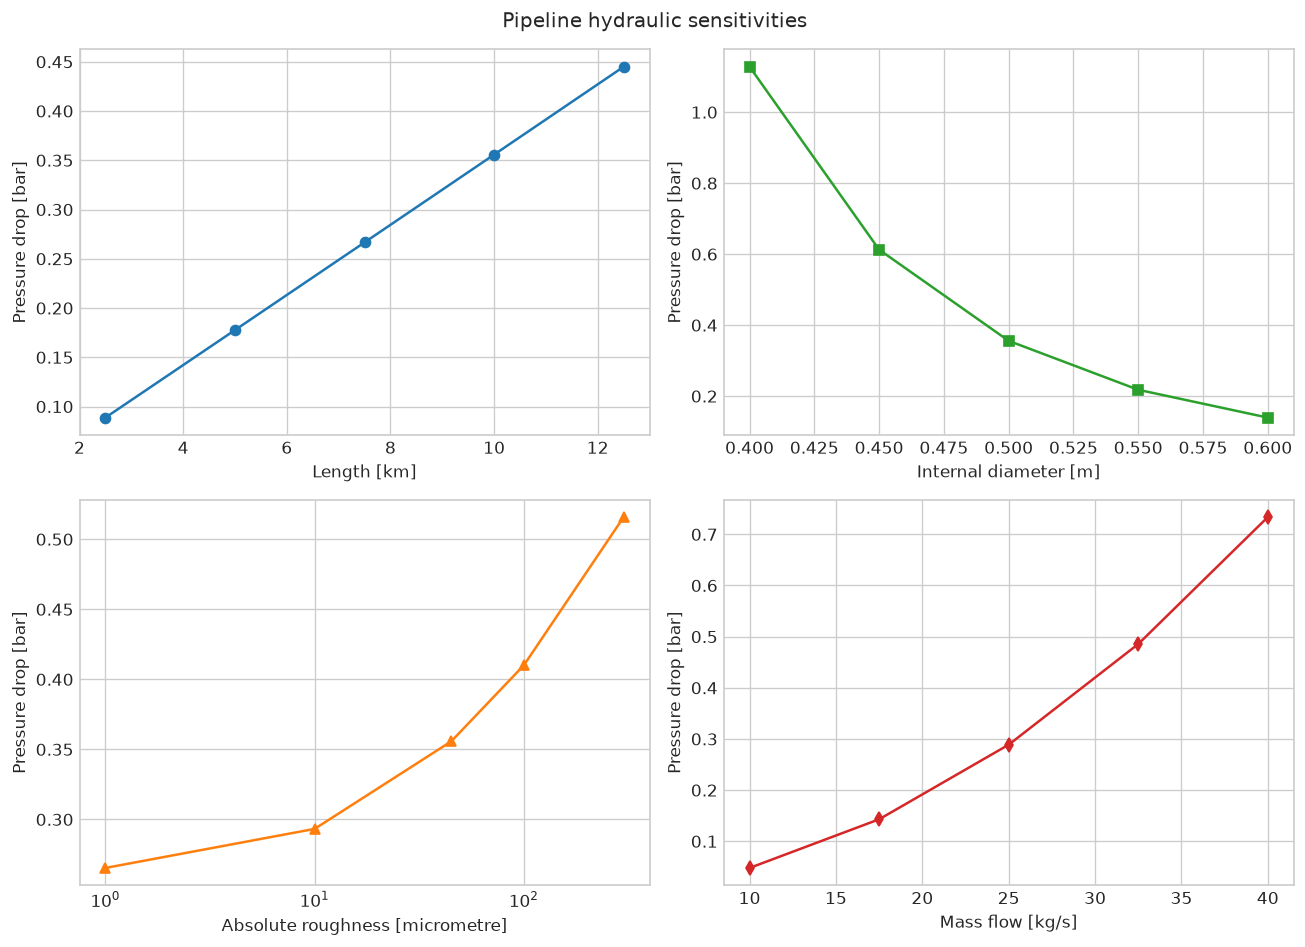

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(
    length_grid_m / 1000.0,
    length_pressure_drops_bara,
    marker="o",
)
axes[0, 0].set_xlabel("Length [km]")
axes[0, 0].set_ylabel("Pressure drop [bar]")

axes[0, 1].plot(
    diameter_grid_m,
    diameter_pressure_drops_bara,
    marker="s",
    color="tab:green",
)
axes[0, 1].set_xlabel("Internal diameter [m]")
axes[0, 1].set_ylabel("Pressure drop [bar]")

axes[1, 0].semilogx(
    roughness_grid_m * 1.0e6,
    roughness_pressure_drops_bara,
    marker="^",
    color="tab:orange",
)
axes[1, 0].set_xlabel("Absolute roughness [micrometre]")
axes[1, 0].set_ylabel("Pressure drop [bar]")

axes[1, 1].plot(
    flow_grid_kg_s,
    flow_pressure_drops_bara,
    marker="d",
    color="tab:red",
)
axes[1, 1].set_xlabel("Mass flow [kg/s]")
axes[1, 1].set_ylabel("Pressure drop [bar]")

fig.suptitle("Pipeline hydraulic sensitivities")
fig.tight_layout()
plt.show()


## Elevation and static head

Elevation adds a gravity term to the mechanical-energy balance:

$$
\Delta p_g \approx \rho g \Delta z
$$

Gas density varies with pressure, so this constant-density expression is only a scale check. Positive
elevation means the outlet is above the inlet. Comparing uphill, horizontal, and downhill cases tests
the sign convention and shows why a route profile matters even for gas.


In [14]:
elevation_grid_m = np.array([-500.0, 0.0, 500.0])
elevation_pressure_drops_bara = []

for elevation_m in elevation_grid_m:
    case_feed, _, case_outlet = run_pipeline(
        mass_flow_kg_s,
        elevation=elevation_m,
    )
    elevation_pressure_drops_bara.append(
        case_feed.getPressure("bara") - case_outlet.getPressure("bara")
    )

elevation_table = pd.DataFrame(
    {
        "Outlet elevation minus inlet [m]": elevation_grid_m,
        "Total pressure drop [bar]": elevation_pressure_drops_bara,
    }
)
print(elevation_table.round(6).to_string(index=False))


 Outlet elevation minus inlet [m]  Total pressure drop [bar]
                           -500.0                  -3.063461
                              0.0                   0.355749
                            500.0                   3.623908


## Validation checks

The final gate combines conservation, phase behaviour, numerical health, an independent reference,
and all expected trends. Assertions are deliberately focused on engineering invariants rather than
exact regression values that could change slightly with a future property-model update.


In [15]:
validation_checks = {
    "composition closure": abs(sum(composition.values()) - 1.0) < 1.0e-12,
    "single gas phase": (
        feed_fluid.getNumberOfPhases() == 1
        and str(gas_phase.getPhaseTypeName()) == "gas"
    ),
    "positive density": inlet_density_kg_m3 > 0.0,
    "positive viscosity": inlet_viscosity_pa_s > 0.0,
    "turbulent inlet": reynolds_number > 4000.0,
    "subsonic inlet": continuity_velocity_m_s < gas_phase.getSoundSpeed(),
    "positive pipeline drop": base_pressure_drop_bara > 0.0,
    "mass closure": abs(base_mass_residual_kg_s) < 1.0e-12,
    "velocity agreement": abs(velocity_residual_m_s) < 0.05,
    "reference pressure scale": 0.10 < pressure_drop_ratio < 1.20,
    "monotonic pressure profile": np.all(np.diff(pressure_profile_bara) < 0.0),
    "finite pressure profile": np.isfinite(pressure_profile_bara).all(),
    "turbulent profile": np.all(reynolds_profile > 4000.0),
    "longer pipe raises drop": np.all(np.diff(length_pressure_drops_bara) > 0.0),
    "larger diameter lowers drop": np.all(
        np.diff(diameter_pressure_drops_bara) < 0.0
    ),
    "rougher wall raises drop": np.all(
        np.diff(roughness_pressure_drops_bara) > 0.0
    ),
    "higher flow raises drop": np.all(np.diff(flow_pressure_drops_bara) > 0.0),
    "uphill raises drop": np.all(np.diff(elevation_pressure_drops_bara) > 0.0),
    "outlet pressure remains positive": base_outlet.getPressure("bara") > 0.0,
    "single-phase regime reported": str(base_pipeline.getFlowRegime()) == "SINGLE_PHASE",
}

failed_checks = [
    name
    for name, passed in validation_checks.items()
    if not passed
]
assert not failed_checks, failed_checks

print(f"Engineering checks passed: {len(validation_checks)}")
print(f"Pressure drop [bar]: {base_pressure_drop_bara:.6f}")
print(f"Mass residual [kg/s]: {base_mass_residual_kg_s:.3e}")
print(f"Pressure-drop reference ratio [-]: {pressure_drop_ratio:.6f}")


Engineering checks passed: 20
Pressure drop [bar]: 0.355749
Mass residual [kg/s]: 0.000e+00
Pressure-drop reference ratio [-]: 0.994815


## Limitations, troubleshooting, and exercises

- Confirm `bara` versus `barg`, `kg/sec` versus `kg/hr`, and internal versus nominal diameter first.
- A negative calculated outlet pressure means the specified inlet pressure cannot deliver that flow
  through the modelled line; treat it as a capacity limit, not a value to clip.
- Add fittings through documented equivalent lengths or loss models rather than hiding them in wall
  roughness. Use a measured route profile when gravity matters.
- For wet gas, liquid loading, slugging, or terrain effects, characterize water and condensate, enable
  the appropriate phases, inspect holdup and regime profiles, and validate against field or laboratory
  data.
- For rapid transients, acoustic waves, detailed local geometry, or CFD, use a suitable dynamic or
  multidimensional model and transfer NeqSim properties with explicit assumptions.

**Exercises.** Add a non-isothermal wall model, replace the synthetic fluid with a documented gas,
evaluate the maximum feasible flow for a minimum arrival pressure, and compare one result with another
published correlation.

## References

- [NeqSim fluid mechanics](https://equinor.github.io/neqsim/fluidmechanics/README.html)
- [NeqSim process simulation](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)

**Summary.** The completed workflow links real-fluid thermodynamics to steady pipeline hydraulics,
checks a transparent friction scale, quantifies the main design sensitivities, and enforces mass,
phase, trend, and numerical-health assertions.
